# Warm-start Benchmark

Compares **cold start** (200 epochs every call) vs **warm start** (200 epochs first call, 50 epochs subsequently) across `N_SEEDS` independent trials.

Metrics:
1. **Optimization performance** – virtual composite objective best-so-far
2. **Computation speed** – per-call and cumulative model training wall-clock time

In [1]:
import sys, time
import numpy as np
import torch

sys.path.append('../')
sys.path.append('../../machineIO/')

from msBO import MultiStateBO
from msBO.objective import BPMvar_minimization
from machineIO import VirtualMachineIO, StatefulOracleEvaluator


Failed to import 'phantasy'


## Benchmark configuration

In [2]:
# ── Reproducibility ──────────────────────────────────────────────────────────
MASTER_SEED = 0
np.random.seed(MASTER_SEED)
torch.manual_seed(MASTER_SEED)

# ── Trial settings ───────────────────────────────────────────────────────────
N_SEEDS  = 15      # independent trials per configuration
N_INIT   = 10      # init oracle calls
N_EACH   = 5       # oracle calls per state per outer loop pass
BETA     = 9
ACQ_TYPE = 'EI'
FIX_ACQ_STATE = False
LOCAL_OPT     = False

# ── Warm-start epochs ────────────────────────────────────────────────────────
COLD_EPOCHS = 200  # always used in cold-start mode
WARM_EPOCHS = 50   # used for calls 2..N in warm-start mode

# ── Problem dimensions ───────────────────────────────────────────────────────
N_CONTROL   = 8
N_BPM       = 2
N_STATE     = 3
N_STATE_PVS = 1


## Problem setup (shared VirtualMachineIO)

In [3]:
control_CSETs  = [f'PSC{i}:I_CSET' for i in range(N_CONTROL)]
control_RDs    = [f'PSC{i}:I_RD'   for i in range(N_CONTROL)]
control_tols   = [0.01] * N_CONTROL
control_min    = [0.0]  * N_CONTROL
control_max    = [1.0]  * N_CONTROL

bpm_xRDs   = [f'BPM{i}:XPOS_RD' for i in range(N_BPM)]
bpm_magRDs = [f'BPM{i}:MAG_RD'  for i in range(N_BPM)]
monitor_PVs = bpm_xRDs + bpm_magRDs

state_CSETs = [f'CSS:POS{i}_CSET' for i in range(N_STATE_PVS)]
state_RDs   = [f'CSS:POS{i}_RD'   for i in range(N_STATE_PVS)]
state_tols  = [0.01] * N_STATE_PVS
state_min   = [0.0]  * N_STATE_PVS
state_max   = [float(N_STATE - 1)] * N_STATE_PVS

state_key_vals   = {f'state{s}': [float(s)] * N_STATE_PVS for s in range(N_STATE)}
oracle_key_names = {'x': control_RDs, 'y': bpm_xRDs + ['BPM:MAG_min_ratio']}
states = list(state_key_vals.keys())

vmIO = VirtualMachineIO(
    control_CSETs = control_CSETs + state_CSETs,
    control_RDs   = control_RDs   + state_RDs,
    monitor_PVs   = monitor_PVs,
    control_min   = control_min + state_min,
    control_max   = control_max + state_max,
    monitor_min   = [-5.0] * N_BPM + [0.8] * N_BPM,
    monitor_max   = [ 5.0] * N_BPM + [1.0] * N_BPM,
    complexity    = 128,
)

x0 = (np.random.rand(N_CONTROL)
      * (np.array(control_max) - np.array(control_min))
      + np.array(control_min))
print("x0:", np.round(x0, 3))

BPM_MAGs_ref = {}
for s, v in state_key_vals.items():
    vmIO.ensure_set(vmIO.control_CSETs, vmIO.control_RDs,
                    np.concatenate([x0, v]), control_tols + state_tols)
    BPM_MAGs_ref[s] = vmIO.fetch_data(bpm_magRDs).mean().values

def BPM_MAG_obj(df, s):
    df['BPM:MAG_min_ratio'] = (
        df[bpm_magRDs].values / BPM_MAGs_ref[s][None, :]
    ).min()
    return df

def make_oracle():
    return StatefulOracleEvaluator(
        vmIO,
        control_CSETs     = control_CSETs,
        control_RDs       = control_RDs,
        control_tols      = control_tols,
        state_CSETs       = state_CSETs,
        state_RDs         = state_RDs,
        state_tols        = state_tols,
        state_key_vals    = state_key_vals,
        oracle_key_names  = oracle_key_names,
        monitor_PVs       = monitor_PVs,
        state_df_manipulators = [BPM_MAG_obj],
    )

composite_objective_function = BPMvar_minimization(
    S=N_STATE, J=len(oracle_key_names['y'])
)


x0: [0.962 0.076 0.393 0.617 0.249 0.637 0.458 0.94 ]


## Single-run helper

In [4]:
def run_once(seed: int, warm_start: bool) -> dict:
    """
    One BO trial.

    Parameters
    ----------
    seed       : random seed
    warm_start : True  → model_warmstart_epochs = WARM_EPOCHS
                 False → model_warmstart_epochs = COLD_EPOCHS  (cold reference)

    Returns dict with:
        vobj_mean   – virtual composite objective per BO step
        train_times – wall-clock seconds per train_model() call
    """
    np.random.seed(seed)
    torch.manual_seed(seed)

    oracle = make_oracle()
    oracle(x=x0, s=states[0])    # reset machine

    msbo = MultiStateBO(
        states       = states,
        tasks        = oracle_key_names['y'],
        control_min  = control_min,
        control_max  = control_max,
        multistate_oracle_evaluator  = oracle,
        composite_objective_function = composite_objective_function,
        local_bound_size = 0.1 * (np.array(control_max) - np.array(control_min)),
        model_train_epochs     = COLD_EPOCHS,
        # warm_start=True  → subsequent calls use WARM_EPOCHS
        # warm_start=False → subsequent calls also use COLD_EPOCHS
        model_warmstart_epochs = WARM_EPOCHS if warm_start else COLD_EPOCHS,
    )

    msbo.init(n_init=N_INIT, local_optimization=LOCAL_OPT)

    # Exact loop from benchmark notebook
    kw = dict(local_optimization=LOCAL_OPT, acq_type=ACQ_TYPE,
              fix_acq_state=FIX_ACQ_STATE, beta=BETA)
    for s in states[::-1]:
        for _ in range(N_EACH):        msbo.step(s=s, **kw)
    for s in states:
        for _ in range(N_EACH - 1):   msbo.step(s=s, **kw)
    for s in states:
        for _ in range(N_EACH - 2):   msbo.step(s=s, **kw)
    for s in states[::-1]:
        for _ in range(N_EACH - 3):   msbo.step(s=s, **kw)

    _, vobj_mean, _ = msbo.virtual_composite_history()
    return {
        'vobj_mean':   list(vobj_mean),
        'train_times': list(msbo.history['time_cost']['model_train']),
    }


## Run all seeds  *(this cell is slow — ~minutes per config)*

In [5]:
results = {}

for label, warm in [('cold_start', False), ('warm_start', True)]:
    print(f"\n{'─'*55}")
    warmup_ep = WARM_EPOCHS if warm else COLD_EPOCHS
    print(f"{label}  (warmstart_epochs={warmup_ep})")
    print(f"{'─'*55}")
    results[label] = []
    for seed in range(N_SEEDS):
        t0 = time.monotonic()
        r  = run_once(seed, warm_start=warm)
        dt = time.monotonic() - t0
        results[label].append(r)
        n_tr   = len(r['train_times'])
        mean_t = np.mean(r['train_times'])
        tot_t  = np.sum(r['train_times'])
        print(f"  seed {seed:2d} | {n_tr} trains | "
              f"mean {mean_t:.2f}s | total {tot_t:.1f}s | wall {dt:.1f}s")

print("\nAll runs complete.")



───────────────────────────────────────────────────────
cold_start  (warmstart_epochs=200)
───────────────────────────────────────────────────────
  seed  0 | 43 trains | mean 1.17s | total 50.5s | wall 69.7s
  seed  1 | 43 trains | mean 1.17s | total 50.4s | wall 69.8s
  seed  2 | 43 trains | mean 1.26s | total 54.4s | wall 69.7s
  seed  3 | 43 trains | mean 1.24s | total 53.3s | wall 72.0s
  seed  4 | 43 trains | mean 1.66s | total 71.3s | wall 104.5s
  seed  5 | 43 trains | mean 1.18s | total 50.8s | wall 71.3s
  seed  6 | 43 trains | mean 1.23s | total 52.9s | wall 74.6s
  seed  7 | 43 trains | mean 1.36s | total 58.5s | wall 79.1s
  seed  8 | 43 trains | mean 1.32s | total 56.9s | wall 73.7s
  seed  9 | 43 trains | mean 1.29s | total 55.6s | wall 76.2s
  seed 10 | 43 trains | mean 1.24s | total 53.3s | wall 73.8s
  seed 11 | 43 trains | mean 1.30s | total 55.8s | wall 70.1s
  seed 12 | 43 trains | mean 1.24s | total 53.3s | wall 73.8s
  seed 13 | 43 trains | mean 1.22s | total 52

## Summary statistics

In [6]:
def train_time_stats(label):
    first = np.array([r['train_times'][0]            for r in results[label]])
    warm  = np.array([np.mean(r['train_times'][1:])  for r in results[label]])
    total = np.array([np.sum(r['train_times'])        for r in results[label]])
    return first, warm, total

def cumulative_best(y):
    return np.maximum.accumulate(np.asarray(y, dtype=float))

def bsf_stats(label):
    seqs    = [r['vobj_mean'] for r in results[label]]
    L       = min(len(s) for s in seqs)
    bsf_arr = np.stack([cumulative_best(s[:L]) for s in seqs], axis=0)
    return bsf_arr.mean(0), np.quantile(bsf_arr, 0.20, 0), np.quantile(bsf_arr, 0.80, 0)

print(f"{'Config':<15} {'1st call (s)':>13} {'warm calls (s)':>15} {'total train (s)':>16} {'final BSF':>11}")
print('─' * 72)
for label in ['cold_start', 'warm_start']:
    first, wm, total = train_time_stats(label)
    m, _, _ = bsf_stats(label)
    print(f"{label:<15} "
          f"{first.mean():>7.2f}±{first.std():.2f}  "
          f"{wm.mean():>8.2f}±{wm.std():.2f}   "
          f"{total.mean():>9.1f}±{total.std():.1f}  "
          f"{m[-1]:>10.4f}")

_, wm_cold, tot_cold = train_time_stats('cold_start')
_, wm_warm, tot_warm = train_time_stats('warm_start')
print(f"\nSpeedup  per warm call : {wm_cold.mean()/wm_warm.mean():.2f}×"
      f"  (expected {COLD_EPOCHS/WARM_EPOCHS:.1f}× from epochs)")
print(f"Speedup  total training: {tot_cold.mean()/tot_warm.mean():.2f}×")


Config           1st call (s)  warm calls (s)  total train (s)   final BSF
────────────────────────────────────────────────────────────────────────
cold_start         1.12±0.19      1.28±0.12        54.7±5.0      0.7743
warm_start         1.04±0.05      0.30±0.00        13.8±0.1      0.7908

Speedup  per warm call : 4.19×  (expected 4.0× from epochs)
Speedup  total training: 3.96×


## Plots

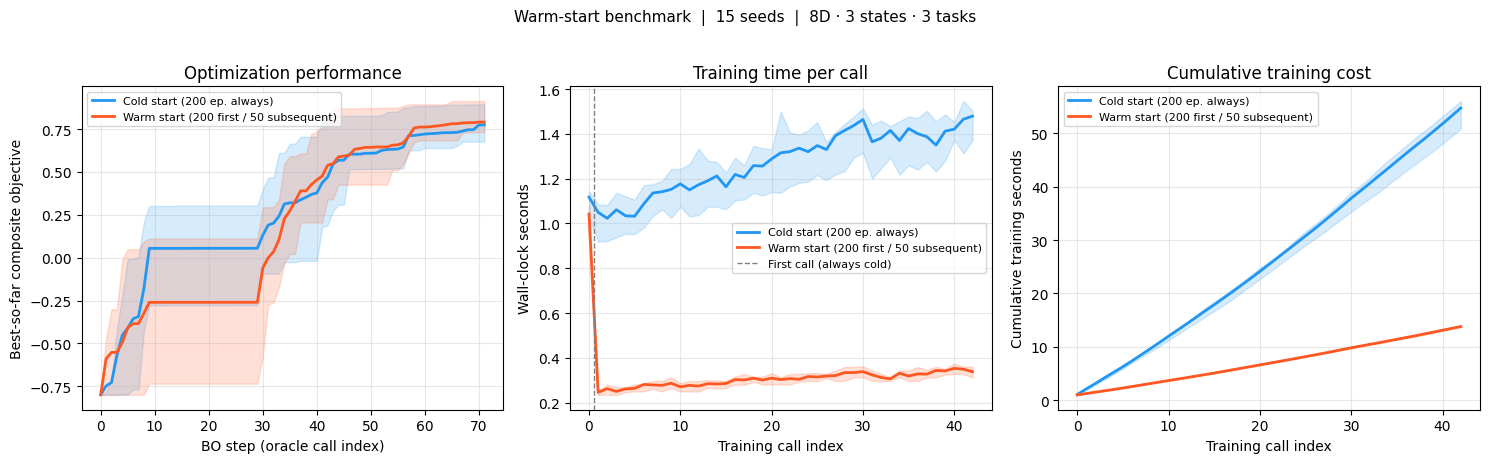

In [7]:
import matplotlib.pyplot as plt

colors = {'cold_start': '#2196F3', 'warm_start': '#FF5722'}
labels = {
    'cold_start': f'Cold start ({COLD_EPOCHS} ep. always)',
    'warm_start': f'Warm start ({COLD_EPOCHS} first / {WARM_EPOCHS} subsequent)',
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# ── Panel 1: best-so-far optimization performance ─────────────────────────────
ax = axes[0]
for lbl in ['cold_start', 'warm_start']:
    m, q20, q80 = bsf_stats(lbl)
    xs = np.arange(len(m))
    ax.plot(xs, m, color=colors[lbl], label=labels[lbl], lw=2)
    ax.fill_between(xs, q20, q80, color=colors[lbl], alpha=0.18)
ax.set_xlabel('BO step (oracle call index)')
ax.set_ylabel('Best-so-far composite objective')
ax.set_title('Optimization performance')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# ── Panel 2: per-call training time across the run ────────────────────────────
ax = axes[1]
for lbl in ['cold_start', 'warm_start']:
    seqs = [r['train_times'] for r in results[lbl]]
    L    = min(len(s) for s in seqs)
    arr  = np.stack([s[:L] for s in seqs])
    m    = arr.mean(0);  q20 = np.quantile(arr, 0.20, 0); q80 = np.quantile(arr, 0.80, 0)
    xs   = np.arange(L)
    ax.plot(xs, m, color=colors[lbl], label=labels[lbl], lw=2)
    ax.fill_between(xs, q20, q80, color=colors[lbl], alpha=0.18)
ax.axvline(0.5, color='grey', ls='--', lw=1, label='First call (always cold)')
ax.set_xlabel('Training call index')
ax.set_ylabel('Wall-clock seconds')
ax.set_title('Training time per call')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# ── Panel 3: cumulative training time ─────────────────────────────────────────
ax = axes[2]
for lbl in ['cold_start', 'warm_start']:
    seqs = [np.cumsum(r['train_times']) for r in results[lbl]]
    L    = min(len(s) for s in seqs)
    arr  = np.stack([s[:L] for s in seqs])
    m    = arr.mean(0);  q20 = np.quantile(arr, 0.20, 0); q80 = np.quantile(arr, 0.80, 0)
    xs   = np.arange(L)
    ax.plot(xs, m, color=colors[lbl], label=labels[lbl], lw=2)
    ax.fill_between(xs, q20, q80, color=colors[lbl], alpha=0.18)
ax.set_xlabel('Training call index')
ax.set_ylabel('Cumulative training seconds')
ax.set_title('Cumulative training cost')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle(
    f'Warm-start benchmark  |  {N_SEEDS} seeds  |  '
    f'{N_CONTROL}D · {N_STATE} states · {N_BPM+1} tasks',
    fontsize=11, y=1.02,
)
plt.tight_layout()
plt.savefig('benchmark_warmstart_plots.png', dpi=150, bbox_inches='tight')
plt.show()
